# CHSH Game: Proving Quantum Non-Locality

This notebook implements the **Clauser-Horne-Shimony-Holt (CHSH) game**, a quantum information protocol used to demonstrate quantum non-locality and break classical bounds.

### Overview & Rules
* **Players:** Alice and Bob, who cannot communicate after receiving their inputs.
* **Referee Inputs:** Random bits $x \in \{0, 1\}$ (to Alice) and $y \in \{0, 1\}$ (to Bob).
* **Player Outputs:** Measurement outcomes $a \in \{0, 1\}$ (from Alice) and $b \in \{0, 1\}$ (from Bob).
* **Winning Condition:** $a \oplus b = x \cdot y$ (equivalent to $a \neq b$ only when $x = 1$ and $y = 1$).

### Theoretical Bounds
* **Classical Strategy Boundary:** $75\%$ win rate max (constrained by Local Hidden Variable theory / Bell's Inequality).
* **Quantum Strategy Boundary:** $\cos^2(\pi/8) \approx 85.35\%$ win rate, achieved via a shared Bell state and optimal measurement basis rotations.

### 1. Environment Setup

Import necessary packages from Qiskit for circuit generation, state preparation, and local simulation.

In [1]:
#importing the necessary classes and functions from the relevant libraries and packages

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
from qiskit import transpile
from qiskit_aer import AerSimulator

### 2. Quantum Circuit Construction

The `create_chsh_circuit` function builds the strategy protocol in four distinct stages:
1. **Entanglement:** Generates the maximally entangled Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ shared between Alice ($q_0$) and Bob ($q_1$).
2. **Alice's Basis Selection ($x$):** Rotates qubit $q_0$ based on input $x$:
   * $x = 0 \implies$ Measure in $Z$-basis ($R_y(0)$)
   * $x = 1 \implies$ Measure in $X$-basis ($R_y(\pi/2)$)
3. **Bob's Basis Selection ($y$):** Rotates qubit $q_1$ based on input $y$:
   * $y = 0 \implies$ Measure in $W$-basis ($R_y(\pi/4)$)
   * $y = 1 \implies$ Measure in $V$-basis ($R_y(-\pi/4)$)
4. **Measurement:** Collapses quantum states to store outcomes $a$ and $b$ in classical bits.

In [3]:
def create_chsh_circuit(x: int, y: int) -> QuantumCircuit:

    qc = QuantumCircuit(2,2)

    # 1. Prepare shared entangled pair |Phi+>
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()
    
    # 2. Alice's basis rotation based on x
    if x == 1:
        qc.ry(np.pi / 2, 0)
        
    # 3. Bob's basis rotation based on y
    if y == 0:
        qc.ry(np.pi / 4, 1)
    else:
        qc.ry(-np.pi / 4, 1)
        
    qc.barrier()
    
    # 4. Measure qubits into classical bits
    qc.measure([0, 1], [0, 1])
    return qc

### 3. Simulation & Empirical Verification

Execute all four input scenarios $(x, y) \in \{(0,0), (0,1), (1,0), (1,1)\}$ on the `AerSimulator`. Calculate the win rate across all shots to demonstrate empirical violation of the classical $75\%$ limit.

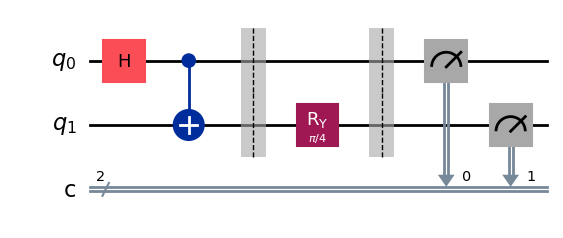

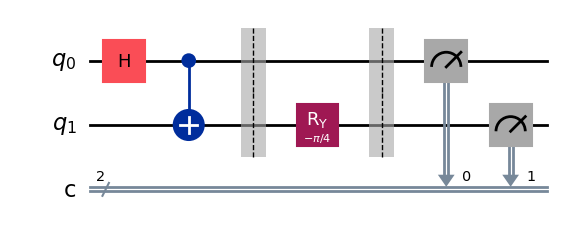

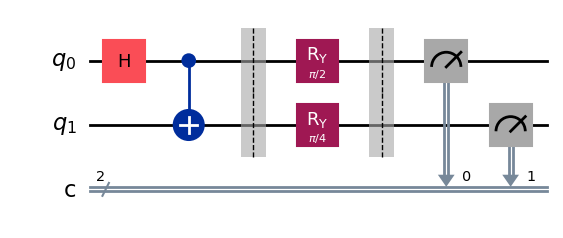

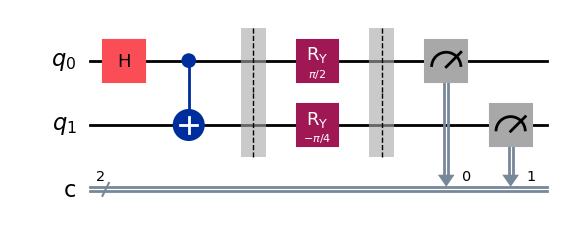

Overall Quantum Strategy Win Rate: 86.08%


In [12]:
#Let's run the simulator

simulator = AerSimulator()
total_wins = 0
num_shots = 1000

#We want to show all four of our scenarios
for x in [0,1]:
    for y in [0,1]:
        qc = create_chsh_circuit(x,y)
        result = simulator.run(qc, shots = num_shots).result()
        state_counts = result.get_counts()

        # Calculate winning outcomes for this (x, y) input pair
        for outcome, count in state_counts.items():
            # Outcome format from Qiskit measurement is string 'b a'
            b, a = int(outcome[0]), int(outcome[1])
            if (a != b) == (x & y): #derived from IBM Basics of Quantum Information Course
                total_wins += count

        display(qc.draw('mpl'))

win_rate = total_wins / (4 * num_shots)
print(f"Overall Quantum Strategy Win Rate: {win_rate * 100:.2f}%")

### 4. Conclusion & Key Takeaways

### Results & Theoretical Verification
* **Simulated Quantum Win Rate:** 86.08% across all four input pair combinations $(x, y)$.
* **Classical Realism Bound:** Maximum achievable win rate is strictly **75%** under Local Hidden Variable (LHV) theories.

### Physical Significance
1. **Violation of Bell's Inequality:** The ~10% performance boost over the best classical strategy empirically refutes local hidden-variable theories, proving that quantum entanglement exhibits non-local correlation.
2. **Role of Basis Transformations:** Entangled states alone are insufficient; optimal non-locality requires rotating Alice's and Bob's measurement axes relative to one another via $R_y$ gates to construct complementary measurement bases.

### Next Steps
* **Hardware Execution:** Submit the circuit to real IBM Quantum devices using `qiskit-ibm-runtime` to measure how readout error and gate noise degrade the quantum win rate toward the classical regime.